In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('instacart.db')
print("Connected!")

Connected!


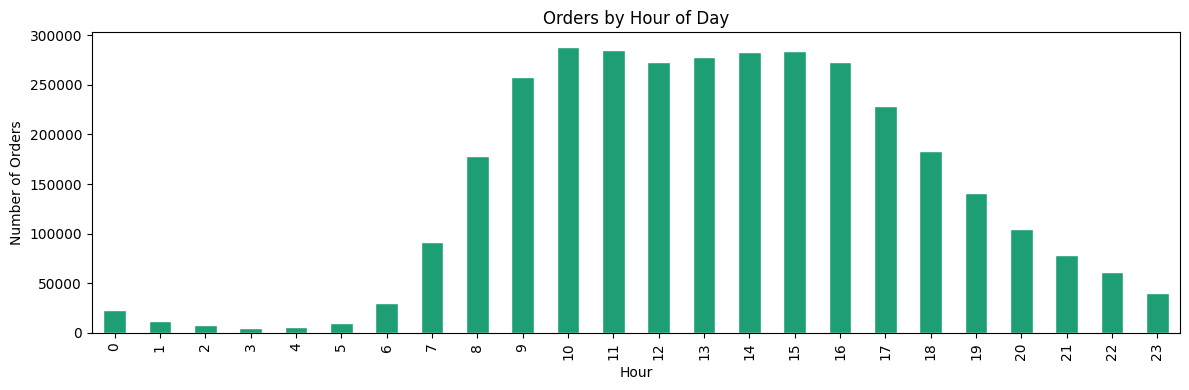

Peak hour: 10 :00


In [2]:
orders = pd.read_sql("SELECT * FROM orders", conn)

plt.figure(figsize=(12, 4))
orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', color='#1D9E75', edgecolor='white')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('exports/01_orders_by_hour.png', dpi=150)
plt.show()
print("Peak hour:", orders['order_hour_of_day'].value_counts().idxmax(), ":00")

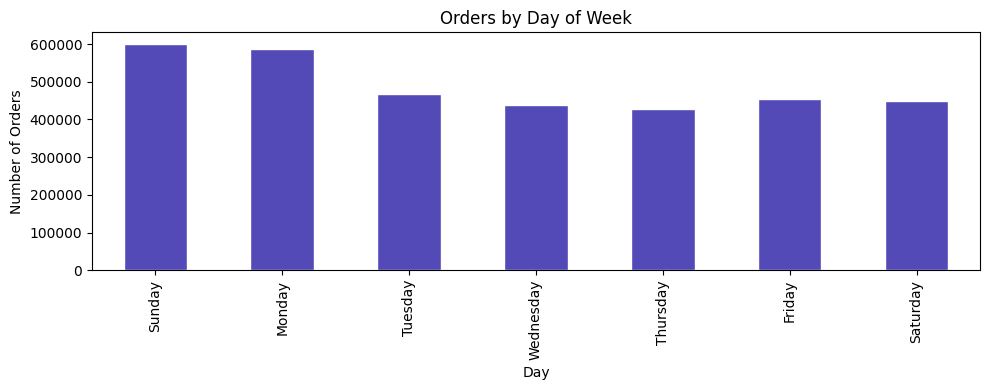

In [3]:
day_map = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday',
           4:'Thursday', 5:'Friday', 6:'Saturday'}

orders['day_name'] = orders['order_dow'].map(day_map)

plt.figure(figsize=(10, 4))
orders['day_name'].value_counts().reindex(day_map.values()).plot(
    kind='bar', color='#534AB7', edgecolor='white')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('exports/02_orders_by_day.png', dpi=150)
plt.show()

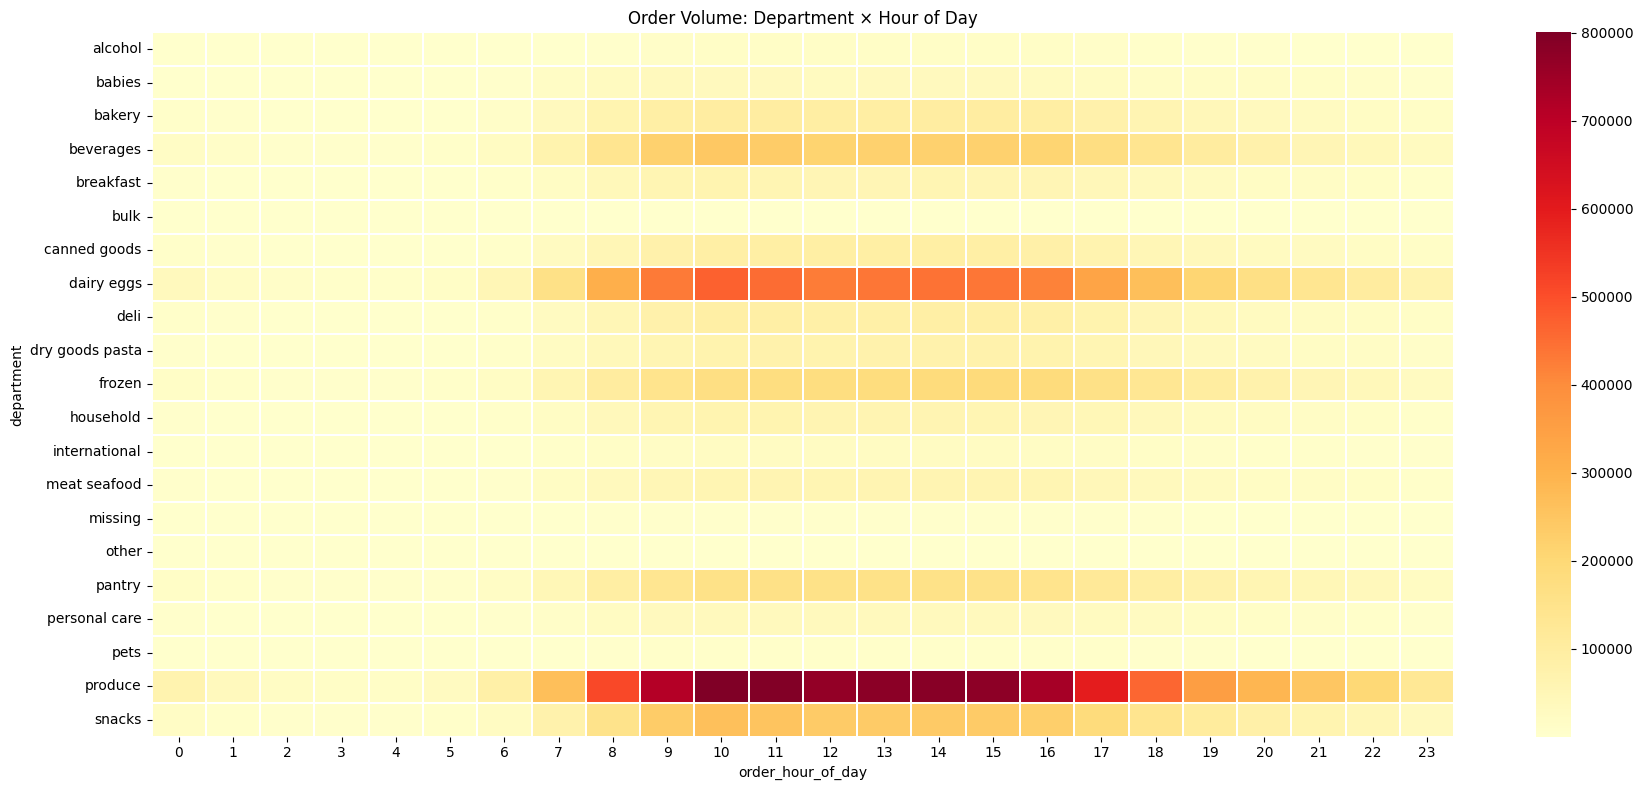

In [5]:
dept_hour = pd.read_sql("""
    SELECT d.department, o.order_hour_of_day, COUNT(*) as volume
    FROM order_products_prior op
    JOIN orders o ON op.order_id = o.order_id
    JOIN products p ON op.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    GROUP BY d.department, o.order_hour_of_day
""", conn)

pivot = dept_hour.pivot(index='department',
                        columns='order_hour_of_day',
                        values='volume').fillna(0)

plt.figure(figsize=(18, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, fmt='.0f')
plt.title('Order Volume: Department × Hour of Day')
plt.tight_layout()
plt.savefig('exports/03_dept_hour_heatmap.png', dpi=150)
plt.show()